# Road Accident Analysis in India
### Aim: To analyze road accident data and find patterns to improve road safety.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
# Loading the dataset
data = pd.read_csv("accident_prediction_india.csv")

# Checking the first few rows to see what the data looks like
print("First 5 rows of the data:")
display(data.head())

# Checking for null values to see if data cleaning is needed
print("\nChecking for missing values:")
print(data.isnull().sum())

First 5 rows of the data:


,State Name,City Name,Year,Month,Day of Week,Time of Day,Accident Severity,Number of Vehicles Involved,Vehicle Type Involved,Number of Casualties,...,Road Type,Road Condition,Lighting Conditions,Traffic Control Presence,Speed Limit (km/h),Driver Age,Driver Gender,Driver License Status,Alcohol Involvement,Accident Location Details
0,Jammu and Kashmir,Unknown,2021,May,Monday,1:46,Serious,5,Cycle,0,...,National Highway,Wet,Dark,Signs,61,66,Male,NaN,Yes,Curve
1,Uttar Pradesh,Lucknow,2018,January,Wednesday,21:30,Minor,5,Truck,5,...,Urban Road,Dry,Dusk,Signs,92,60,Male,NaN,Yes,Straight Road
2,Chhattisgarh,Unknown,2023,May,Wednesday,5:37,Minor,5,Pedestrian,6,...,National Highway,Under Construction,Dawn,Signs,120,26,Female,NaN,No,Bridge
3,Uttar Pradesh,Lucknow,2020,June,Saturday,0:31,Minor,3,Bus,10,...,State Highway,Dry,Dark,Signals,76,34,Female,Valid,Yes,Straight Road
4,Sikkim,Unknown,2021,August,Thursday,11:21,Minor,5,Cycle,7,...,Urban Road,Wet,Dusk,Signs,115,30,Male,NaN,No,Intersection



Checking for missing values:
State Name                       0
City Name                        0
Year                             0
Month                            0
Day of Week                      0
Time of Day                      0
Accident Severity                0
Number of Vehicles Involved      0
Vehicle Type Involved            0
Number of Casualties             0
Number of Fatalities             0
Weather Conditions               0
Road Type                        0
Road Condition                   0
Lighting Conditions              0
Traffic Control Presence       716
Speed Limit (km/h)               0
Driver Age                       0
Driver Gender                    0
Driver License Status          975
Alcohol Involvement              0
Accident Location Details        0
dtype: int64


In [25]:
# Handling missing values by filling them instead of dropping rows
# This preserves our data size for better analysis
data['Traffic Control Presence'] = data['Traffic Control Presence'].fillna('Unknown')
data['Driver License Status'] = data['Driver License Status'].fillna('Not Checked')

# Creating the final cleaned dataframe
df = data.copy()

print("Data cleaning complete!")
print(f"Total records preserved: {len(df)}")

Data cleaning complete!
Total records preserved: 3000


## Summary Statistics
Let's calculate some basic numbers to understand the average impact of these accidents.

In [26]:
# Calculating basic averages
avg_age = df['Driver Age'].mean()
avg_casualties = df['Number of Casualties'].mean()

print(f"Average Driver Age: {round(avg_age, 2)} years")
print(f"Average Casualties per Accident: {round(avg_casualties, 2)}")

# Checking the count of each severity level
print("\nAccident Severity Breakdown:")
print(df['Accident Severity'].value_counts())

Average Driver Age: 44.18 years
Average Casualties per Accident: 5.07

Accident Severity Breakdown:
Accident Severity
Minor      1034
Fatal       985
Serious     981
Name: count, dtype: int64


## Visualization 1: Top 5 States with Most Accidents
This chart shows which states need more safety measures.

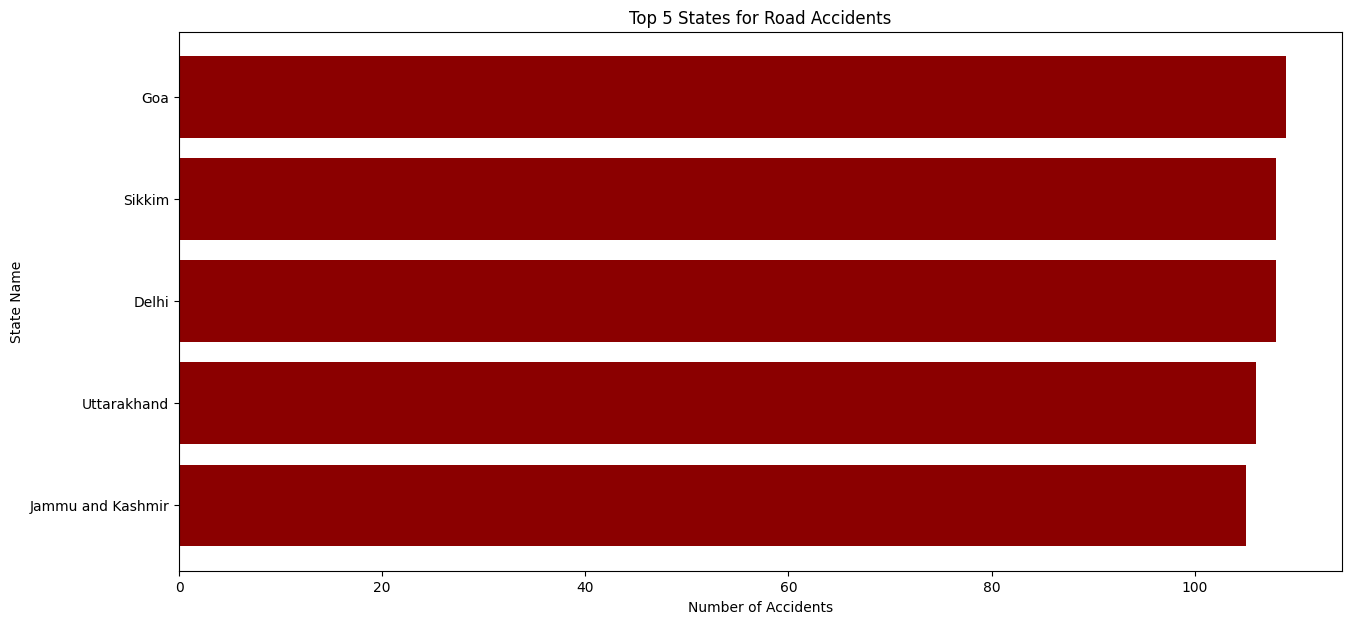

In [36]:
# Counting accidents per state
state_counts = df['State Name'].value_counts().head(5)

# Plotting a Bar Chart (Horizontal)
plt.figure(figsize=(15,7))
plt.barh(state_counts.index, state_counts.values, color='darkred')
plt.title('Top 5 States for Road Accidents')
plt.xlabel('Number of Accidents')
plt.ylabel('State Name')
plt.gca().invert_yaxis()
plt.show()

## Visualization 2: Weather and Accidents
We are using a pie chart to see if weather conditions like rain or storm cause more accidents.

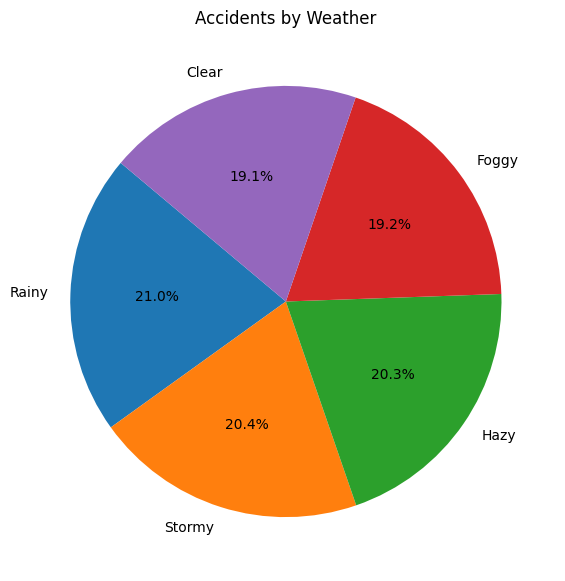

In [37]:
# Grouping by weather
# We use 'df' which is our cleaned copy of the data
weather_info = df['Weather Conditions'].value_counts()

# Making a Pie Chart
plt.figure(figsize=(7,7))
plt.pie(weather_info, labels=weather_info.index, startangle=140, autopct='%1.1f%%')
plt.title('Accidents by Weather')
plt.show()

## Visualization 3: Yearly Trend
Is the number of accidents going up or down over the years?

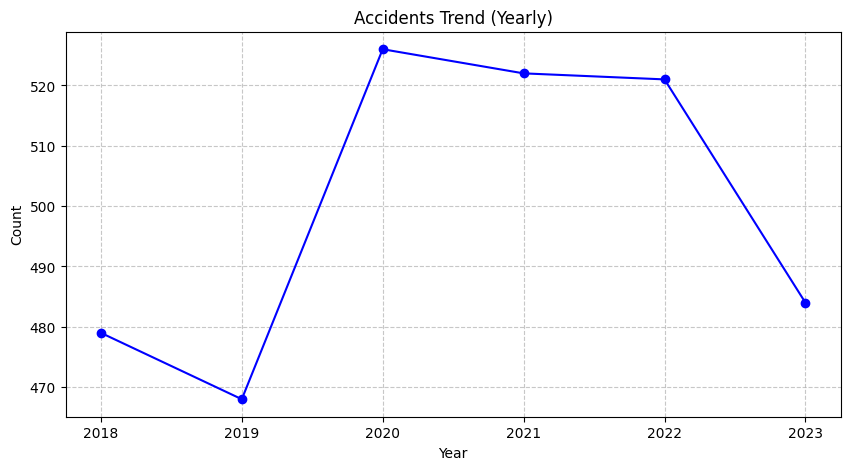

In [38]:
# Grouping by Year using our dataframe 'df'
yearly_data = df.groupby('Year').size()

# Line Plot to show progress over time
plt.figure(figsize=(10,5))
plt.plot(yearly_data.index, yearly_data.values, marker='o', color='blue')
plt.title('Accidents Trend (Yearly)')
plt.xlabel('Year')
plt.ylabel('Count')
plt.grid(True, alpha=0.7, linestyle="--")
plt.show()

## Visualization 4: Alcohol Related Accidents
Analyzing how many accidents involve alcohol across different states.

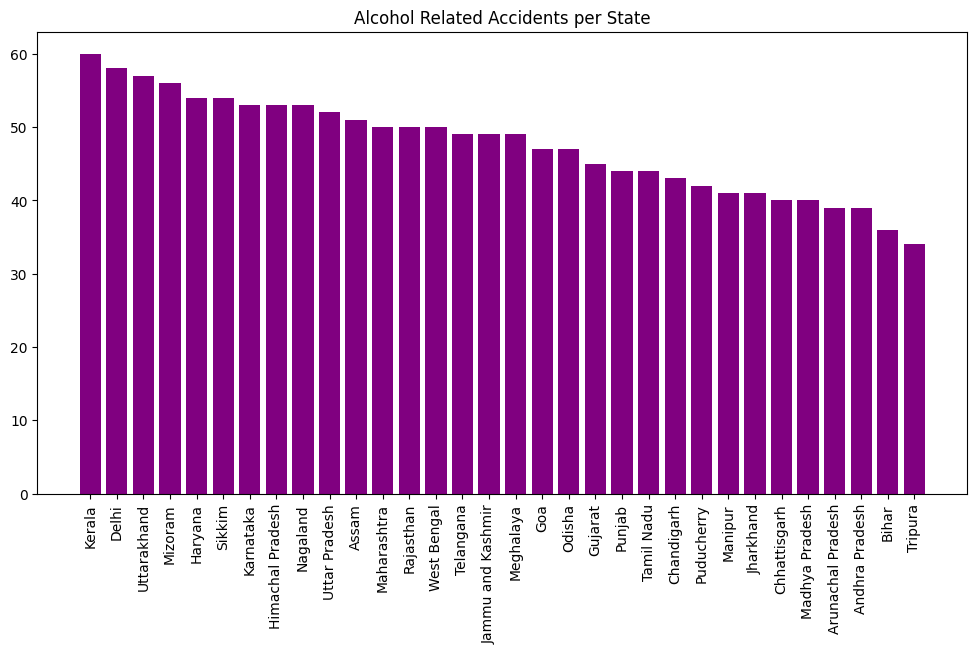

In [39]:
# Filtering only 'Yes' for Alcohol from our dataframe 'df'
alcohol_cases = df[df['Alcohol Involvement'] == 'Yes']
state_alcohol = alcohol_cases['State Name'].value_counts()

# Bar Chart for specific state analysis
plt.figure(figsize=(12,6))
plt.bar(state_alcohol.index, state_alcohol.values, color='purple')
plt.xticks(rotation=90)
plt.title('Alcohol Related Accidents per State')
plt.show()

## Final Conclusion
Based on this analysis, we can see that weather conditions and alcohol play a major role in road safety. Focusing on specific states like Kerala and improving safety during rainy weather could help reduce the number of accidents.